In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score

import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Hp\Downloads\food delivery costs.csv")
df.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0


In [2]:
!pip install xgboost

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order ID                1000 non-null   int64 
 1   Customer ID             1000 non-null   object
 2   Restaurant ID           1000 non-null   object
 3   Order Date and Time     1000 non-null   object
 4   Delivery Date and Time  1000 non-null   object
 5   Order Value             1000 non-null   int64 
 6   Delivery Fee            1000 non-null   int64 
 7   Payment Method          1000 non-null   object
 8   Discounts and Offers    815 non-null    object
 9   Commission Fee          1000 non-null   int64 
 10  Payment Processing Fee  1000 non-null   int64 
 11  Refunds/Chargebacks     1000 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 93.9+ KB


In [4]:
df["Order Date and Time"] = pd.to_datetime(df['Order Date and Time'])
df["Delivery Date and Time"] = pd.to_datetime(df["Delivery Date and Time"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order ID                1000 non-null   int64         
 1   Customer ID             1000 non-null   object        
 2   Restaurant ID           1000 non-null   object        
 3   Order Date and Time     1000 non-null   datetime64[ns]
 4   Delivery Date and Time  1000 non-null   datetime64[ns]
 5   Order Value             1000 non-null   int64         
 6   Delivery Fee            1000 non-null   int64         
 7   Payment Method          1000 non-null   object        
 8   Discounts and Offers    815 non-null    object        
 9   Commission Fee          1000 non-null   int64         
 10  Payment Processing Fee  1000 non-null   int64         
 11  Refunds/Chargebacks     1000 non-null   int64         
dtypes: datetime64[ns](2), int64(6), object(4)
memory 

In [5]:
def extract(value):
    a = str(value).split(" ")
    return a[0]

df["Discounts and Offers"] = df["Discounts and Offers"].apply(extract)

def removep(value):
    if "%" in value:
        a = value.replace("%","")
        return float(a)
    else:
        return float(value)

df["Discounts and Offers"] = df["Discounts and Offers"].apply(removep)


df.loc[(df["Discounts and Offers"] <= 15),"Discounts and Offers" ] = (df["Discounts and Offers"]/100) * df["Order Value"]


df["Discounts and Offers"] = df["Discounts and Offers"].fillna(0)

df.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,95.70,150,47,0
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,98.60,198,23,0
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,140.55,195,45,0
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,0.00,146,27,0
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50.00,130,50,0


In [6]:
#feature engeneering

df["Costs"] = df["Delivery Fee"] + df['Discounts and Offers'] + df["Payment Processing Fee"]
df["Profit"] = df["Commission Fee"] - df['Costs']

df["Delivery Time"] = (df["Delivery Date and Time"] - df["Order Date and Time"]).dt.total_seconds()/60

 
le = LabelEncoder()
df["payment method encoded"] = le.fit_transform(df["Payment Method"])

df["is_loss"] = df["Profit"] < 0

df["month"] = df["Order Date and Time"].dt.month
df["day"] = df["Order Date and Time"].dt.day_name()
df["hour"] = df["Order Date and Time"].dt.hour
df["is_weekend"] = df["day"].isin(["Saturday","Sunday"]).astype(int)
df["time_slot"] = pd.cut(df["hour"],
                        bins=[0,6,12,18,24],
                        labels=["Night","Morning","Afternoon","Evening"])

df["profit_margin"] = df["Profit"] / df["Order Value"]
df["cost_ratio"] = df["Costs"] / df["Order Value"]

df.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,...,Delivery Time,payment method encoded,is_loss,month,day,hour,is_weekend,time_slot,profit_margin,cost_ratio
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,95.70,150,...,88.0,1,False,2,Thursday,1,0,Night,0.003814,0.074556
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,98.60,198,...,35.0,2,False,2,Friday,22,0,Evening,0.036917,0.163895
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,140.55,195,...,58.0,0,True,1,Wednesday,5,0,Night,-0.021932,0.230043
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,0.00,146,...,46.0,0,False,1,Tuesday,22,0,Evening,0.047163,0.052632
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50.00,130,...,89.0,0,False,1,Monday,1,0,Night,0.000000,0.065261


In [7]:
df["Profit"].sum()

np.float64(-5751.85)

In [8]:
cost_dist = df[["Delivery Fee", "Payment Processing Fee", "Discounts and Offers"]].sum()
cost_dist

Delivery Fee              28620.00
Payment Processing Fee    29832.00
Discounts and Offers      74289.85
dtype: float64

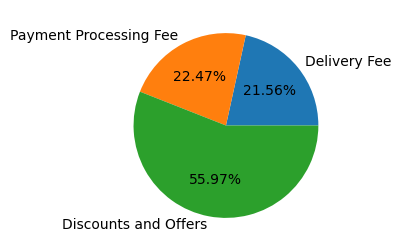

In [9]:
plt.figure(figsize = (3,3))
plt.pie(cost_dist, labels = cost_dist.index, autopct = "%1.2f%%")
plt.show()

In [10]:
abc = df[["Commission Fee", "Costs","Profit"]].sum()
abc

Commission Fee    126990.00
Costs             132741.85
Profit             -5751.85
dtype: float64

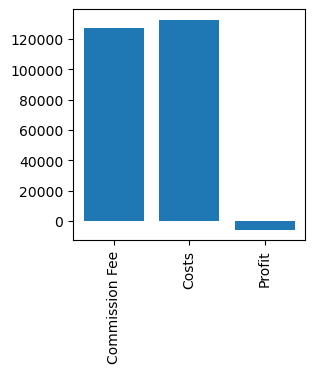

In [11]:
plt.figure(figsize = (3,3))
plt.bar(abc.index, abc)
plt.xticks(rotation = 90)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_5876\513908662.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["COD", "Net Banking", "Credit Card"])


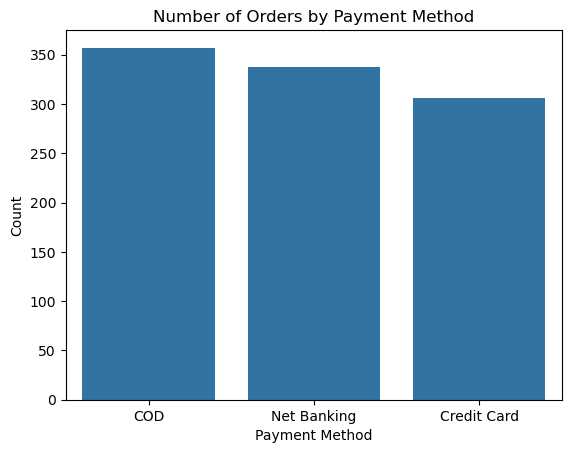

In [12]:
ax=sns.countplot(x="payment method encoded", data=df)

plt.title("Number of Orders by Payment Method")
ax.set_xticklabels(["COD", "Net Banking", "Credit Card"])
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

In [13]:
df.corr(numeric_only=True)["Profit"]

Order ID                 -0.039783
Order Value              -0.416395
Delivery Fee             -0.149315
Discounts and Offers     -0.827629
Commission Fee            0.548110
Payment Processing Fee   -0.158261
Refunds/Chargebacks       0.014395
Costs                    -0.861893
Profit                    1.000000
Delivery Time             0.015237
payment method encoded    0.071430
is_loss                  -0.784261
month                     0.000535
hour                     -0.006320
is_weekend                0.004490
profit_margin             0.679573
cost_ratio               -0.057408
Name: Profit, dtype: float64

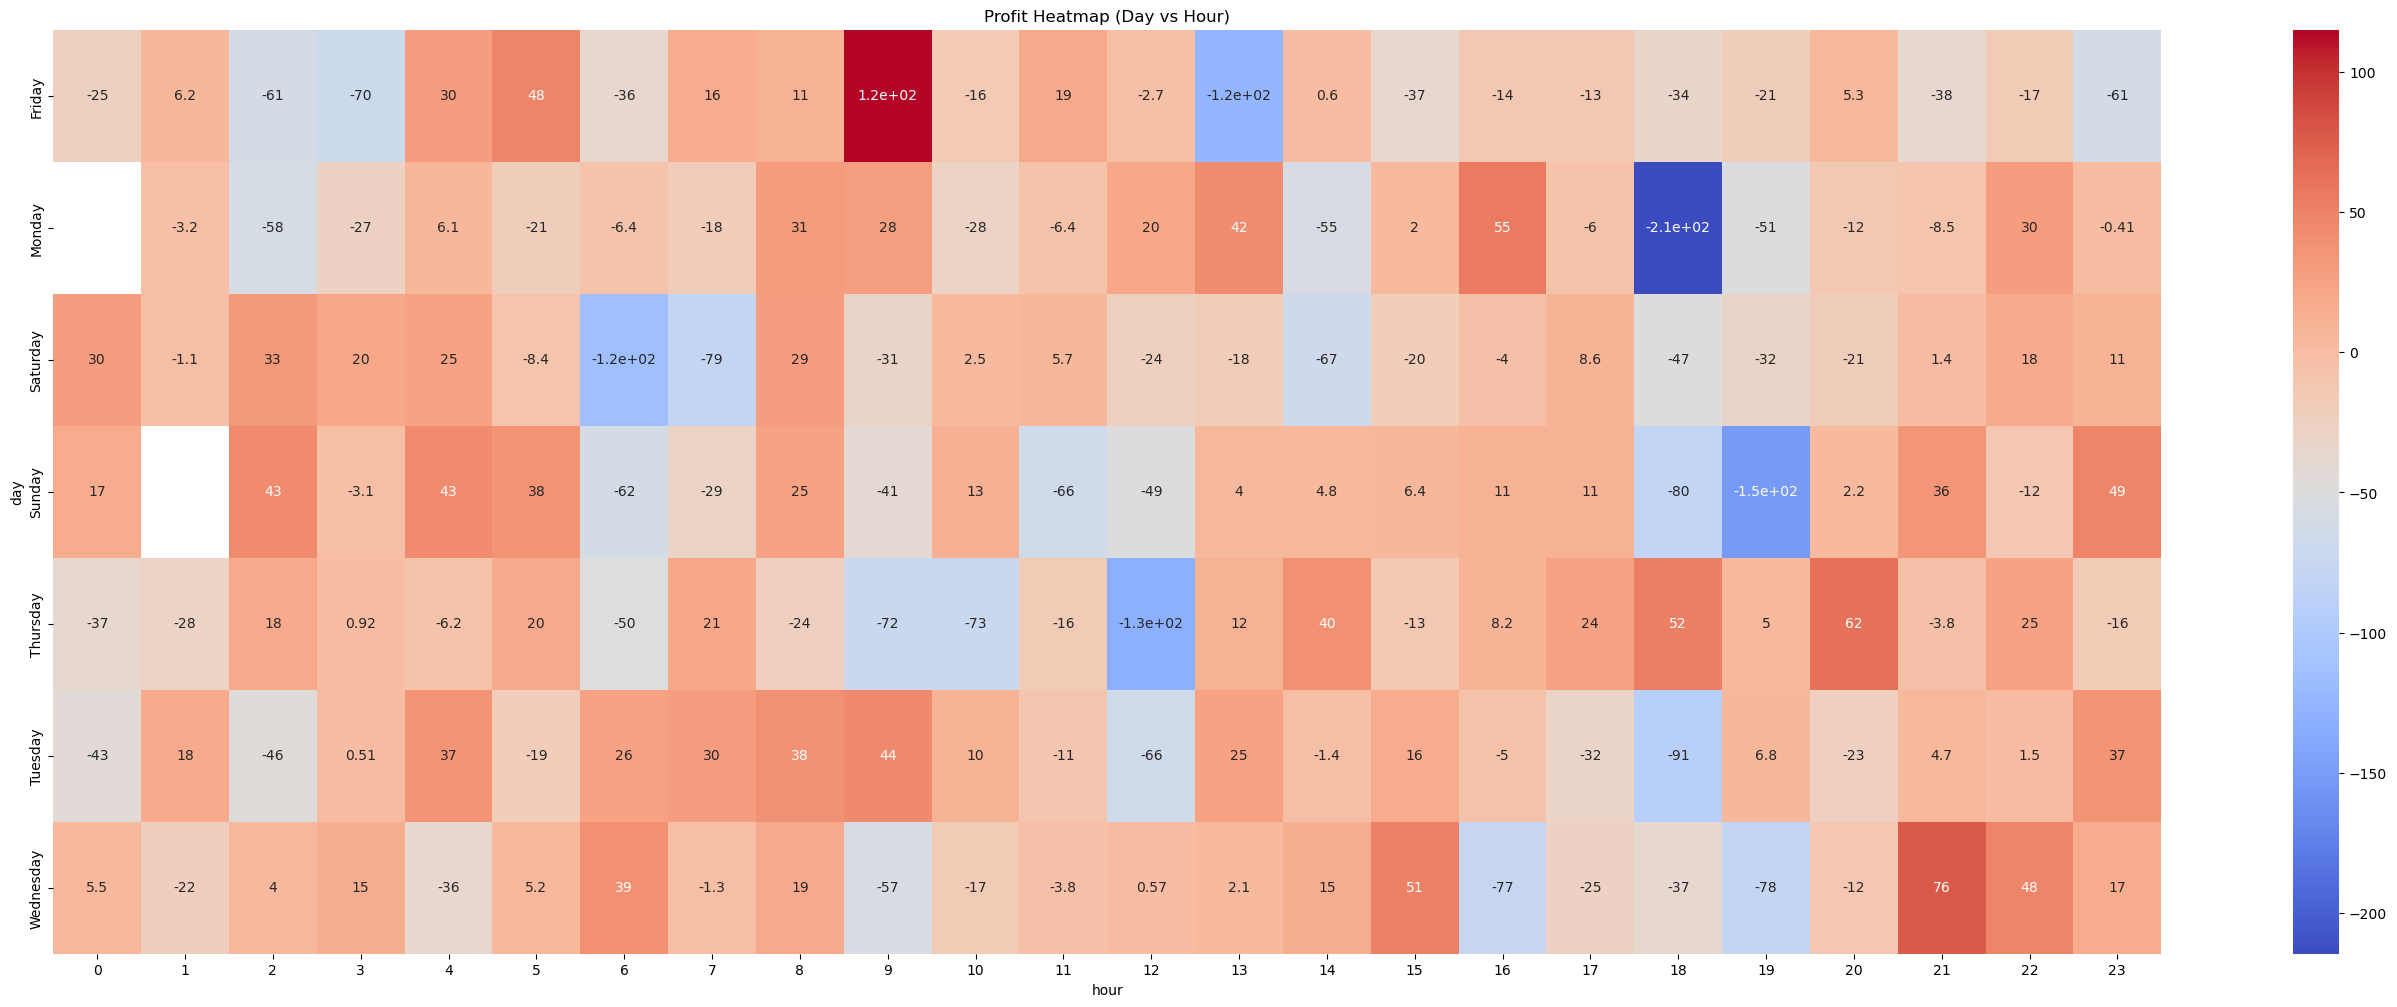

In [14]:
df["hour"] = df["Order Date and Time"].dt.hour
df["day"] = df["Order Date and Time"].dt.day_name()

 
pivot = df.pivot_table(values="Profit", index="day", columns="hour")


plt.figure(figsize=(34,12))
sns.heatmap(pivot, cmap="coolwarm", annot=True)
plt.title("Profit Heatmap (Day vs Hour)")
plt.show()

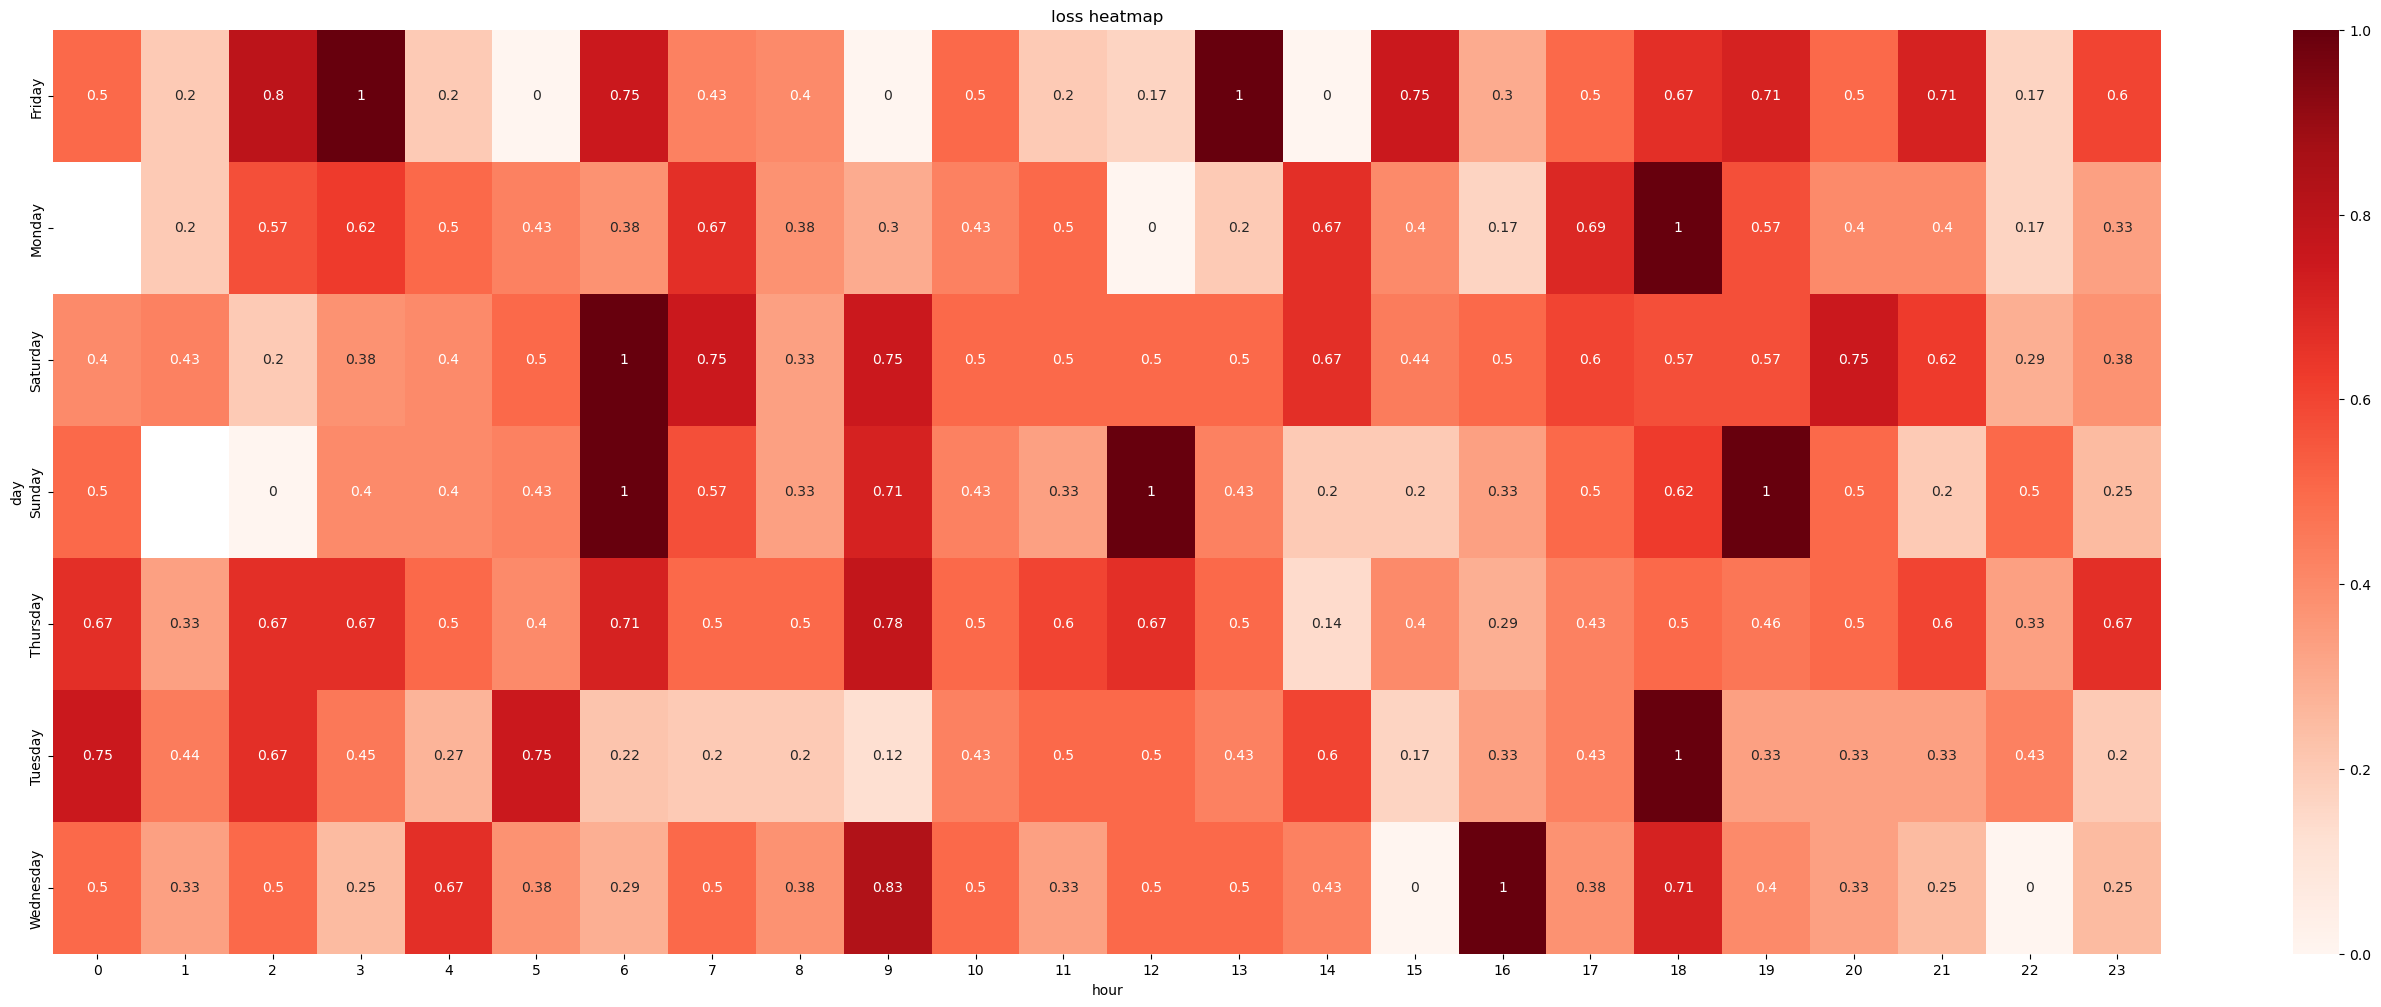

In [15]:
pivot = df.pivot_table(values="is_loss", index="day", columns="hour")


plt.figure(figsize=(34,12))
sns.heatmap(pivot, cmap="Reds", annot=True)
plt.title("loss heatmap")
plt.show()

In [16]:
features = ["Costs", "Delivery Time" , "Discounts and Offers" , "Refunds/Chargebacks" ,"Discounts and Offers" ]
            

X = df[features]
y = df["Profit"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 35.58262942948792
MSE: 1729.7487391232437
R2 Score: 0.7327868355473999


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(importance)

                Feature  Coefficient
1         Delivery Time     0.049769
4  Discounts and Offers    -0.001803
2  Discounts and Offers    -0.001803
3   Refunds/Chargebacks    -0.033272
0                 Costs    -1.029279


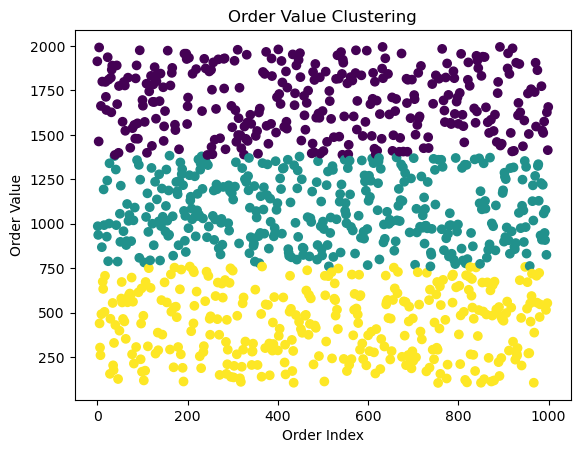

In [18]:
X= df[["Order Value"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.groupby("cluster")["Order Value"].mean()
df.groupby("cluster")["Profit"].mean()

df["cluster_label"] = df["cluster"].map({
    0: "Low Value",
    1: "Medium Value",
    2: "High Value"
})
df.groupby("cluster")["is_loss"].mean()


plt.scatter(df.index, df["Order Value"], c=df["cluster"])

plt.xlabel("Order Index")
plt.ylabel("Order Value")
plt.title("Order Value Clustering")

plt.show()

In [19]:
X = df[[
    "Order Value",
    "Delivery Time",
    "payment method encoded"
]]
y = df["is_loss"].astype(int)
#y = df["is_loss"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.79      0.65        92
           1       0.72      0.46      0.56       108

    accuracy                           0.61       200
   macro avg       0.64      0.63      0.61       200
weighted avg       0.65      0.61      0.61       200



In [20]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=0.2)


model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # tree depth
    class_weight="balanced", # important for loss detection
    random_state=42
)

model.fit(X1_train, y1_train)

y_pred = model.predict(X1_test)

from sklearn.metrics import classification_report

print(classification_report(y1_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.68      0.67       111
           1       0.59      0.58      0.59        89

    accuracy                           0.64       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.64      0.63       200



In [21]:
model = RandomForestRegressor(n_estimators=200)

In [22]:
model = XGBClassifier(scale_pos_weight=2)

In [23]:
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test, y_pred))

[[52 40]
 [60 48]]
0.5048309178743962


<Axes: xlabel='Payment Method', ylabel='Profit'>

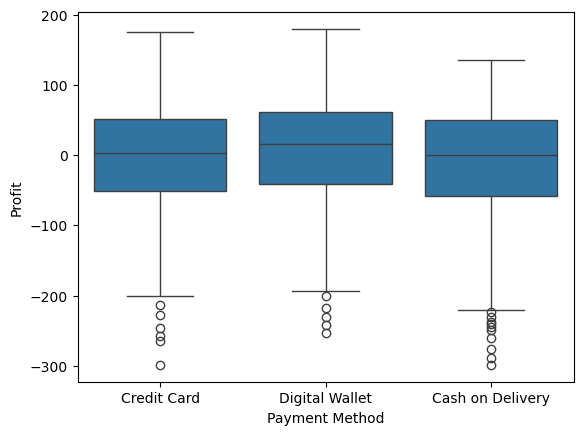

In [24]:
sns.boxplot(x="Payment Method", y="Profit", data=df)

In [26]:
df.groupby("time_slot", observed=True)["Profit"].mean()

time_slot
Night        -3.800965
Morning      -6.677400
Afternoon   -10.379303
Evening      -1.594340
Name: Profit, dtype: float64